# Regularization in Linear Regression - Code Examples
**MAD-B3-2526-S2-MAT0611**

This notebook demonstrates L1 (Lasso) and L2 (Ridge) regularization techniques to prevent overfitting in linear regression.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

---

## Part 1: The Overfitting Problem

Let's start by demonstrating overfitting with polynomial regression.

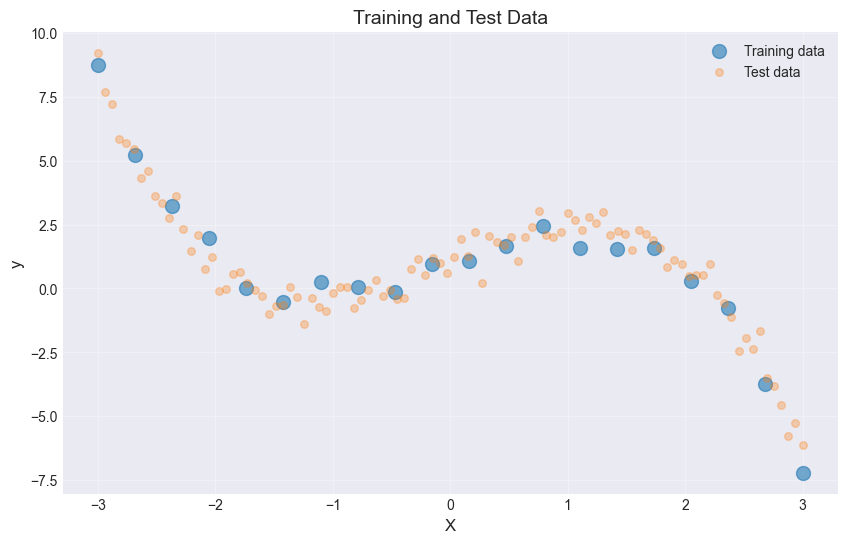

In [35]:
# Generate synthetic data
def generate_data(n_samples=30, noise=0.5):
    """Generate data from y = -0.5x**3 + 2x + 1 + noise"""
    X = np.linspace(-3, 3, n_samples)
    y = -0.5 * X**3 + 2 * X + 1 + noise * np.random.randn(n_samples)
    return X.reshape(-1, 1), y


# Generate training and test data
X_train, y_train = generate_data(n_samples=20, noise=0.5)
X_test, y_test = generate_data(n_samples=100, noise=0.5)

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.6, label="Training data", s=100)
plt.scatter(X_test, y_test, alpha=0.3, label="Test data", s=30)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Training and Test Data", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Comparing Different Polynomial Degrees

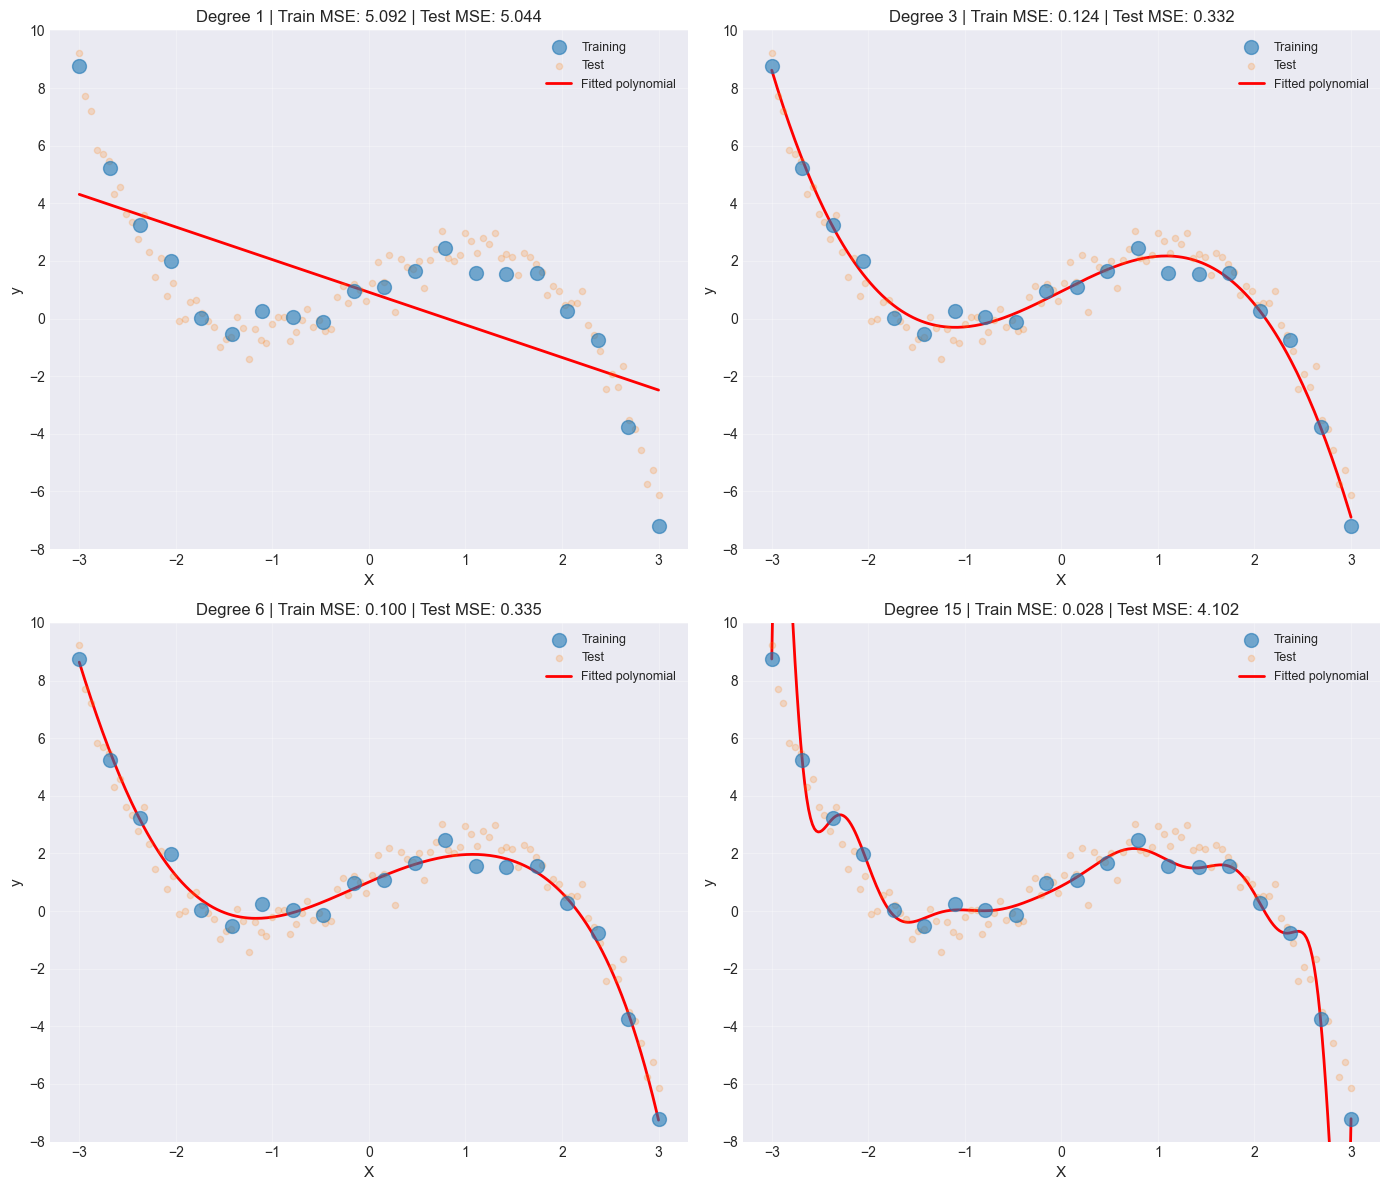


Overfitting Analysis
Degree     Params     Train MSE       Test MSE        Max |Coef|     
----------------------------------------------------------------------
1          2          5.0916          5.0440          1.13e+00       
3          4          0.1236          0.3320          1.70e+00       
6          7          0.0997          0.3352          1.45e+00       
15         16         0.0278          4.1019          3.63e+00       

Notice: As degree increases, training error decreases but test error increases
Coefficients become extremely large → overfitting


In [36]:
# Fit polynomials of different degrees
degrees = [1, 3, 6, 15]
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

results = []

for idx, degree in enumerate(degrees):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_plot_poly = poly.transform(X_plot)

    # Fit OLS
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_plot_pred = model.predict(X_plot_poly)

    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store results
    results.append(
        {
            "degree": degree,
            "train_mse": train_mse,
            "test_mse": test_mse,
            "n_params": X_train_poly.shape[1],
            "max_coef": np.max(np.abs(model.coef_)),
        }
    )

    # Plot
    axes[idx].scatter(X_train, y_train, alpha=0.6, label="Training", s=100, zorder=3)
    axes[idx].scatter(X_test, y_test, alpha=0.2, label="Test", s=20, zorder=2)
    axes[idx].plot(
        X_plot, y_plot_pred, "r-", linewidth=2, label="Fitted polynomial", zorder=1
    )
    axes[idx].set_xlabel("X", fontsize=11)
    axes[idx].set_ylabel("y", fontsize=11)
    axes[idx].set_title(
        f"Degree {degree} | Train MSE: {train_mse:.3f} | Test MSE: {test_mse:.3f}",
        fontsize=12,
    )
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-8, 10)

plt.tight_layout()
plt.show()

# Print coefficient information
print("\n" + "=" * 70)
print("Overfitting Analysis")
print("=" * 70)
print(
    f"{'Degree':<10} {'Params':<10} {'Train MSE':<15} {'Test MSE':<15} {'Max |Coef|':<15}"
)
print("-" * 70)
for r in results:
    print(
        f"{r['degree']:<10} {r['n_params']:<10} {r['train_mse']:<15.4f} {r['test_mse']:<15.4f} {r['max_coef']:<15.2e}"
    )
print(
    "\nNotice: As degree increases, training error decreases but test error increases"
)
print("Coefficients become extremely large → overfitting")

---

## Part 2: Ridge Regression (L2 Regularization)

Ridge adds penalty $\lambda \|\boldsymbol{\beta}\|_2^2$ to shrink coefficients.

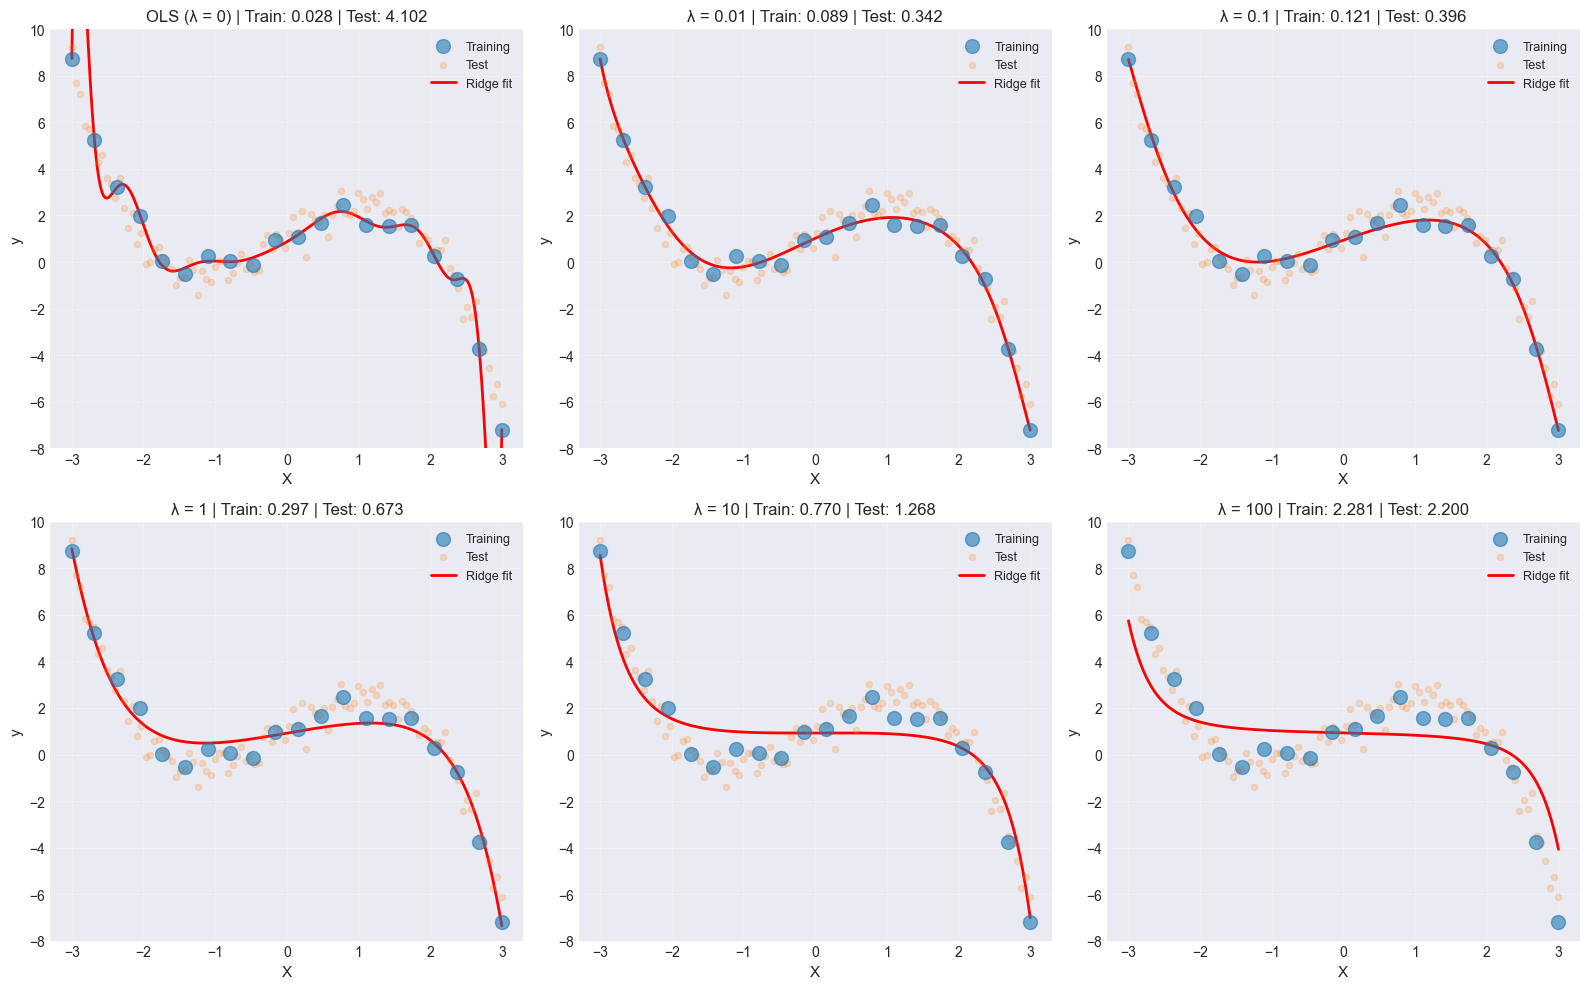


Ridge Regression Results (Degree 15 polynomial)
Lambda       Train MSE       Test MSE        ||β||₂          Non-zero    
--------------------------------------------------------------------------------
0            0.0278          4.1019          19762.34        15          
0.01         0.0894          0.3417          5.81            15          
0.1          0.1212          0.3961          3.76            15          
1            0.2971          0.6732          2.20            15          
10           0.7704          1.2681          1.08            15          
100          2.2811          2.2000          0.64            15          

Notice: As λ increases, coefficients shrink but remain non-zero
Test error improves with moderate regularization


In [37]:
# Use high-degree polynomial
degree = 15
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_plot_poly = poly.transform(X_plot)

# Standardize features (important for regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)
X_plot_scaled = scaler.transform(X_plot_poly)

# Try different lambda values
alphas = [0, 0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

ridge_results = []

for idx, alpha in enumerate(alphas):
    # Fit Ridge
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_plot_pred = model.predict(X_plot_scaled)

    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store results
    ridge_results.append(
        {
            "alpha": alpha,
            "train_mse": train_mse,
            "test_mse": test_mse,
            "l2_norm": np.linalg.norm(model.coef_),
            "n_nonzero": np.sum(np.abs(model.coef_) > 1e-5),
        }
    )

    # Plot
    axes[idx].scatter(X_train, y_train, alpha=0.6, label="Training", s=100, zorder=3)
    axes[idx].scatter(X_test, y_test, alpha=0.2, label="Test", s=20, zorder=2)
    axes[idx].plot(X_plot, y_plot_pred, "r-", linewidth=2, label="Ridge fit", zorder=1)
    axes[idx].set_xlabel("X", fontsize=11)
    axes[idx].set_ylabel("y", fontsize=11)

    title = f"λ = {alpha}" if alpha > 0 else "OLS (λ = 0)"
    axes[idx].set_title(
        f"{title} | Train: {train_mse:.3f} | Test: {test_mse:.3f}", fontsize=12
    )
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-8, 10)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "=" * 80)
print("Ridge Regression Results (Degree 15 polynomial)")
print("=" * 80)
print(
    f"{'Lambda':<12} {'Train MSE':<15} {'Test MSE':<15} {'||β||₂':<15} {'Non-zero':<12}"
)
print("-" * 80)
for r in ridge_results:
    print(
        f"{r['alpha']:<12} {r['train_mse']:<15.4f} {r['test_mse']:<15.4f} {r['l2_norm']:<15.2f} {r['n_nonzero']:<12}"
    )
print("\nNotice: As λ increases, coefficients shrink but remain non-zero")
print("Test error improves with moderate regularization")

### Ridge Coefficient Path

Visualize how coefficients change as $\lambda$ varies.

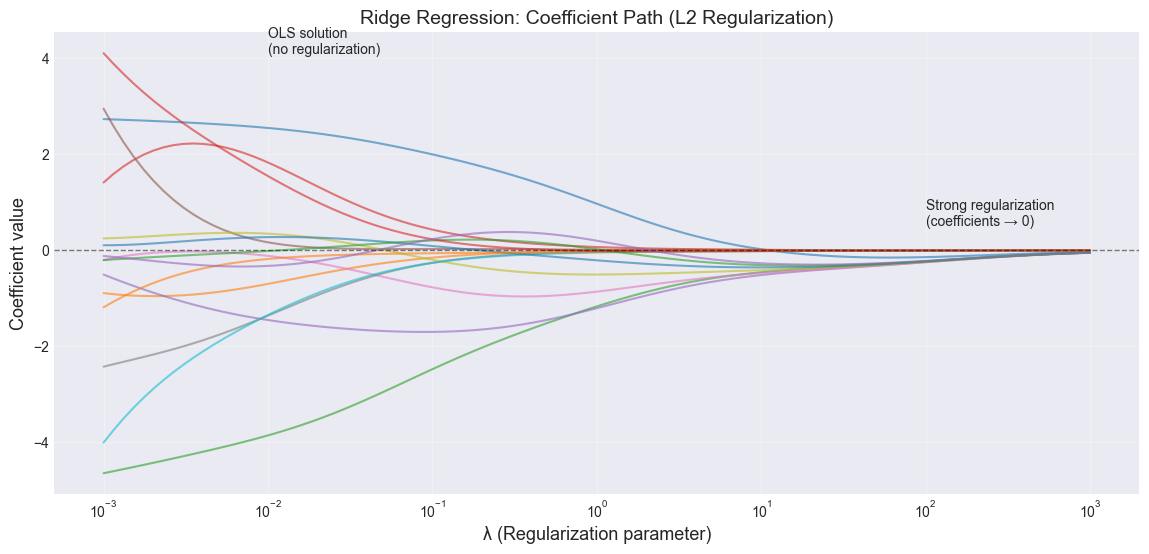


Ridge path shows smooth, continuous shrinkage
All coefficients remain non-zero


In [38]:
# Compute Ridge path
alphas_path = np.logspace(-3, 3, 100)
coefs = []

for alpha in alphas_path:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

# Plot coefficient paths
plt.figure(figsize=(14, 6))
for i in range(coefs.shape[1]):
    plt.plot(alphas_path, coefs[:, i], alpha=0.6)

plt.xscale("log")
plt.xlabel("λ (Regularization parameter)", fontsize=13)
plt.ylabel("Coefficient value", fontsize=13)
plt.title("Ridge Regression: Coefficient Path (L2 Regularization)", fontsize=14)
plt.axhline(y=0, color="k", linestyle="--", linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.text(0.01, plt.ylim()[1] * 0.9, "OLS solution\n(no regularization)", fontsize=10)
plt.text(100, 0.5, "Strong regularization\n(coefficients → 0)", fontsize=10)
plt.show()

print("\nRidge path shows smooth, continuous shrinkage")
print("All coefficients remain non-zero")

---

## Part 3: Lasso Regression (L1 Regularization)

Lasso adds penalty $\lambda \|\boldsymbol{\beta}\|_1$ and can set coefficients exactly to zero.

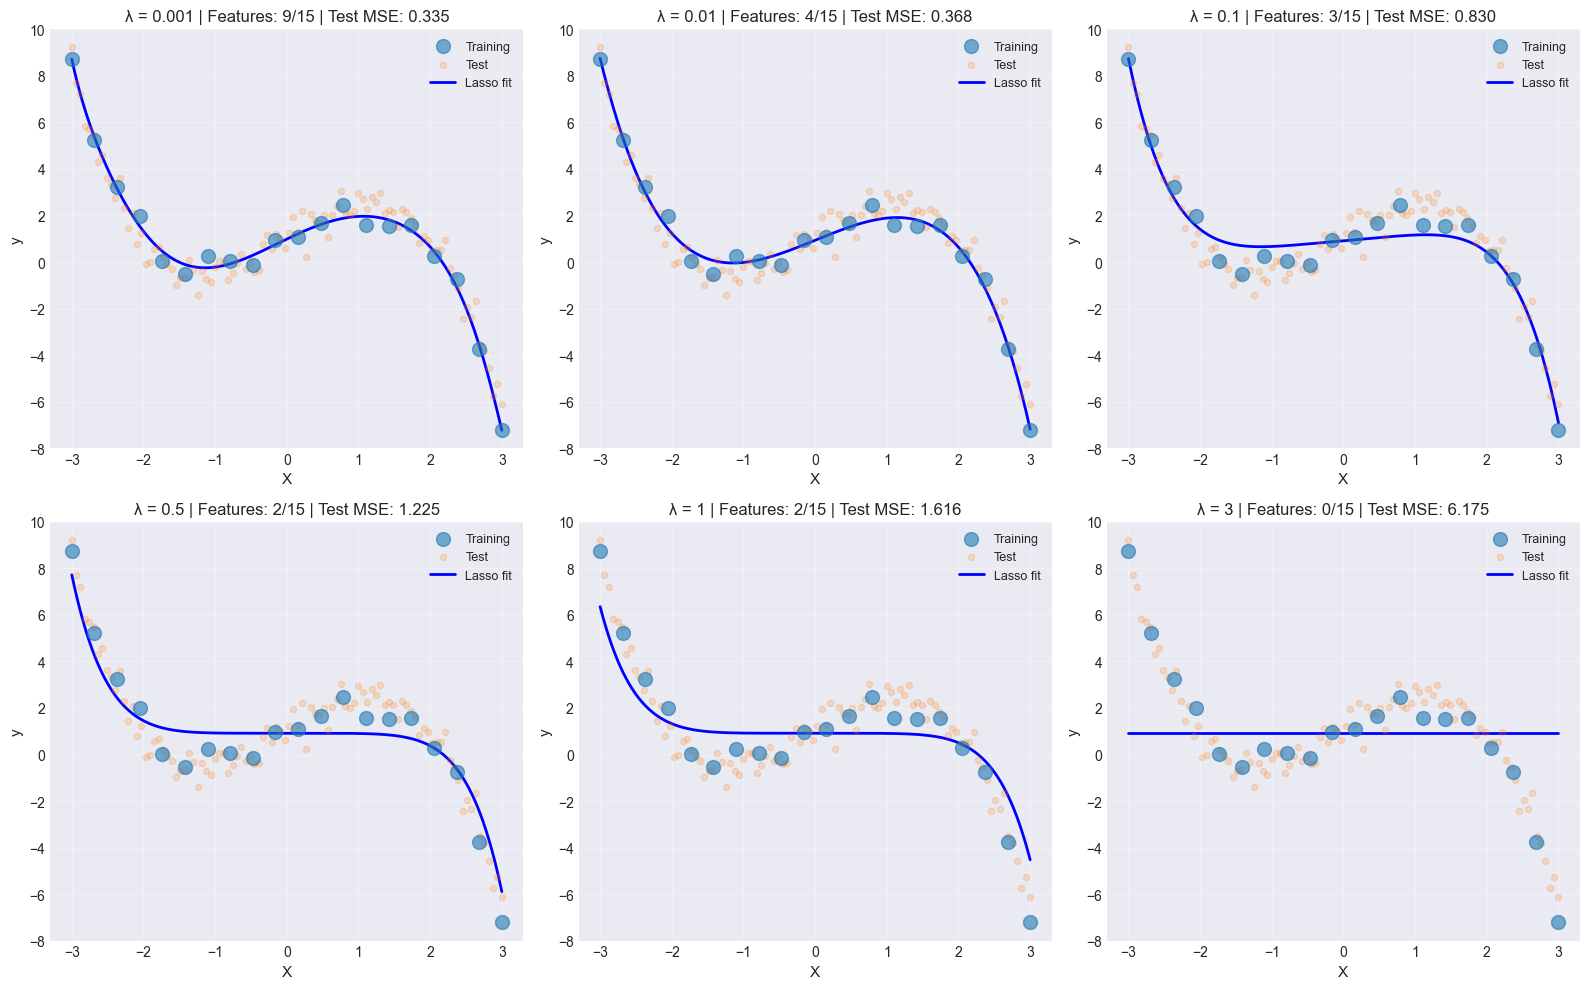


Lasso Regression Results (Degree 15 polynomial)
Lambda       Train MSE       Test MSE        ||β||₁          Non-zero    
--------------------------------------------------------------------------------
0.001        0.0929          0.3350          12.17           9           
0.01         0.1132          0.3677          7.23            4           
0.1          0.3834          0.8304          3.77            3           
0.5          0.8422          1.2250          2.46            2           
1            1.5960          1.6160          1.96            2           
3            9.3397          6.1749          0.00            0           

Notice: As λ increases, number of non-zero coefficients decreases
Lasso performs automatic feature selection


In [39]:
# Try different lambda values for Lasso
alphas_lasso = [0.001, 0.01, 0.1, 0.5, 1, 3]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

lasso_results = []

for idx, alpha in enumerate(alphas_lasso):
    # Fit Lasso
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_plot_pred = model.predict(X_plot_scaled)

    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store results
    lasso_results.append(
        {
            "alpha": alpha,
            "train_mse": train_mse,
            "test_mse": test_mse,
            "l1_norm": np.sum(np.abs(model.coef_)),
            "n_nonzero": np.sum(np.abs(model.coef_) > 1e-5),
        }
    )

    # Plot
    axes[idx].scatter(X_train, y_train, alpha=0.6, label="Training", s=100, zorder=3)
    axes[idx].scatter(X_test, y_test, alpha=0.2, label="Test", s=20, zorder=2)
    axes[idx].plot(X_plot, y_plot_pred, "b-", linewidth=2, label="Lasso fit", zorder=1)
    axes[idx].set_xlabel("X", fontsize=11)
    axes[idx].set_ylabel("y", fontsize=11)

    n_features = lasso_results[-1]["n_nonzero"]
    axes[idx].set_title(
        f"λ = {alpha} | Features: {n_features}/15 | Test MSE: {test_mse:.3f}",
        fontsize=12,
    )
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-8, 10)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "=" * 80)
print("Lasso Regression Results (Degree 15 polynomial)")
print("=" * 80)
print(
    f"{'Lambda':<12} {'Train MSE':<15} {'Test MSE':<15} {'||β||₁':<15} {'Non-zero':<12}"
)
print("-" * 80)
for r in lasso_results:
    print(
        f"{r['alpha']:<12} {r['train_mse']:<15.4f} {r['test_mse']:<15.4f} {r['l1_norm']:<15.2f} {r['n_nonzero']:<12}"
    )
print("\nNotice: As λ increases, number of non-zero coefficients decreases")
print("Lasso performs automatic feature selection")

### Lasso Coefficient Path

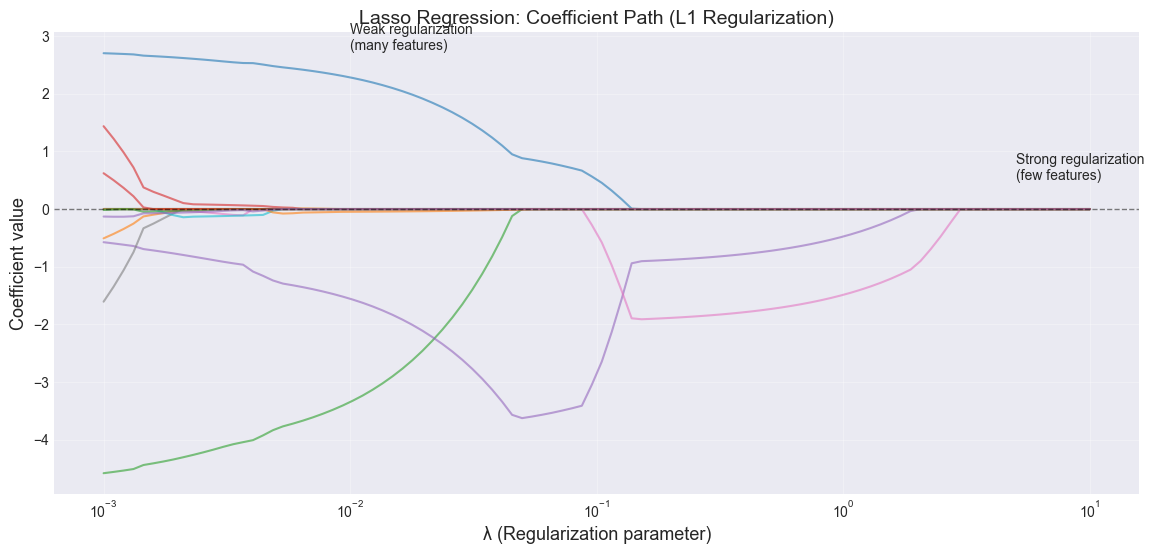


Lasso path shows coefficients hitting zero at different λ values
Sparsity increases with λ (automatic feature selection)


In [40]:
# Compute Lasso path
alphas_path_lasso = np.logspace(-3, 1, 100)
coefs_lasso = []

for alpha in alphas_path_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

# Plot coefficient paths
plt.figure(figsize=(14, 6))
for i in range(coefs_lasso.shape[1]):
    plt.plot(alphas_path_lasso, coefs_lasso[:, i], alpha=0.6)

plt.xscale("log")
plt.xlabel("λ (Regularization parameter)", fontsize=13)
plt.ylabel("Coefficient value", fontsize=13)
plt.title("Lasso Regression: Coefficient Path (L1 Regularization)", fontsize=14)
plt.axhline(y=0, color="k", linestyle="--", linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.text(0.01, plt.ylim()[1] * 0.9, "Weak regularization\n(many features)", fontsize=10)
plt.text(5, 0.5, "Strong regularization\n(few features)", fontsize=10)
plt.show()

print("\nLasso path shows coefficients hitting zero at different λ values")
print("Sparsity increases with λ (automatic feature selection)")

---

## Part 4: Bayesian Interpretation

Regularization corresponds to placing priors on coefficients:
- **Ridge** = Gaussian prior
- **Lasso** = Laplace prior

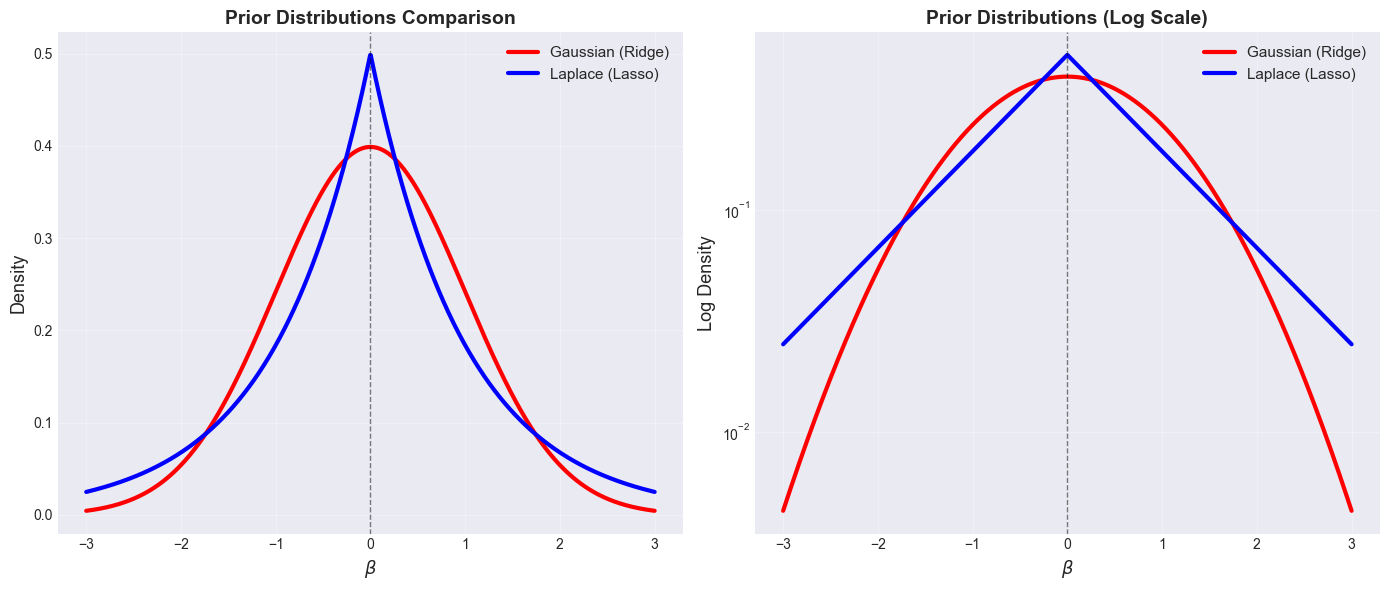


Bayesian Interpretation

 Ridge (L2) ≡ Gaussian Prior:
  • p(β) ∝ exp(-β²/(2τ²))
  • Smooth, symmetric around zero
  • Encourages small coefficients but not exactly zero
  • Gaussian tails decay quickly (light tails)

 Lasso (L1) ≡ Laplace Prior:
  • p(β) ∝ exp(-|β|/b)
  • Peaked at zero (higher density than Gaussian)
  • Encourages exact zeros (sparsity)
  • Heavy tails → allows some large coefficients

 MAP Estimation = Regularized Regression:
  • Ridge: Maximize posterior with Gaussian prior
  • Lasso: Maximize posterior with Laplace prior


In [41]:
# Visualize prior distributions
beta_values = np.linspace(-3, 3, 1000)

# Gaussian prior (Ridge)
tau = 1.0  # Prior standard deviation
gaussian_prior = (1 / (np.sqrt(2 * np.pi) * tau)) * np.exp(
    -(beta_values**2) / (2 * tau**2)
)

# Laplace prior (Lasso)
b = 1.0  # Prior scale parameter
laplace_prior = (1 / (2 * b)) * np.exp(-np.abs(beta_values) / b)

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(beta_values, gaussian_prior, "r-", linewidth=3, label="Gaussian (Ridge)")
plt.plot(beta_values, laplace_prior, "b-", linewidth=3, label="Laplace (Lasso)")
plt.xlabel(r"$\beta$", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.title("Prior Distributions Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color="k", linestyle="--", linewidth=1, alpha=0.5)

# Log scale to see tails
plt.subplot(1, 2, 2)
plt.semilogy(beta_values, gaussian_prior, "r-", linewidth=3, label="Gaussian (Ridge)")
plt.semilogy(beta_values, laplace_prior, "b-", linewidth=3, label="Laplace (Lasso)")
plt.xlabel(r"$\beta$", fontsize=13)
plt.ylabel("Log Density", fontsize=13)
plt.title("Prior Distributions (Log Scale)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color="k", linestyle="--", linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("Bayesian Interpretation")
print("=" * 80)
print("\n Ridge (L2) ≡ Gaussian Prior:")
print(f"  • p(β) ∝ exp(-β²/(2τ²))")
print("  • Smooth, symmetric around zero")
print("  • Encourages small coefficients but not exactly zero")
print("  • Gaussian tails decay quickly (light tails)")
print("\n Lasso (L1) ≡ Laplace Prior:")
print(f"  • p(β) ∝ exp(-|β|/b)")
print("  • Peaked at zero (higher density than Gaussian)")
print("  • Encourages exact zeros (sparsity)")
print("  • Heavy tails → allows some large coefficients")
print("\n MAP Estimation = Regularized Regression:")
print("  • Ridge: Maximize posterior with Gaussian prior")
print("  • Lasso: Maximize posterior with Laplace prior")
print("=" * 80)

---

## Part 6: Cross-Validation for λ Selection

Use cross-validation to choose the best regularization parameter.

Performing Ridge Cross-Validation...
Best Ridge λ: 0.9103

Performing Lasso Cross-Validation...
Best Lasso λ: 0.0105


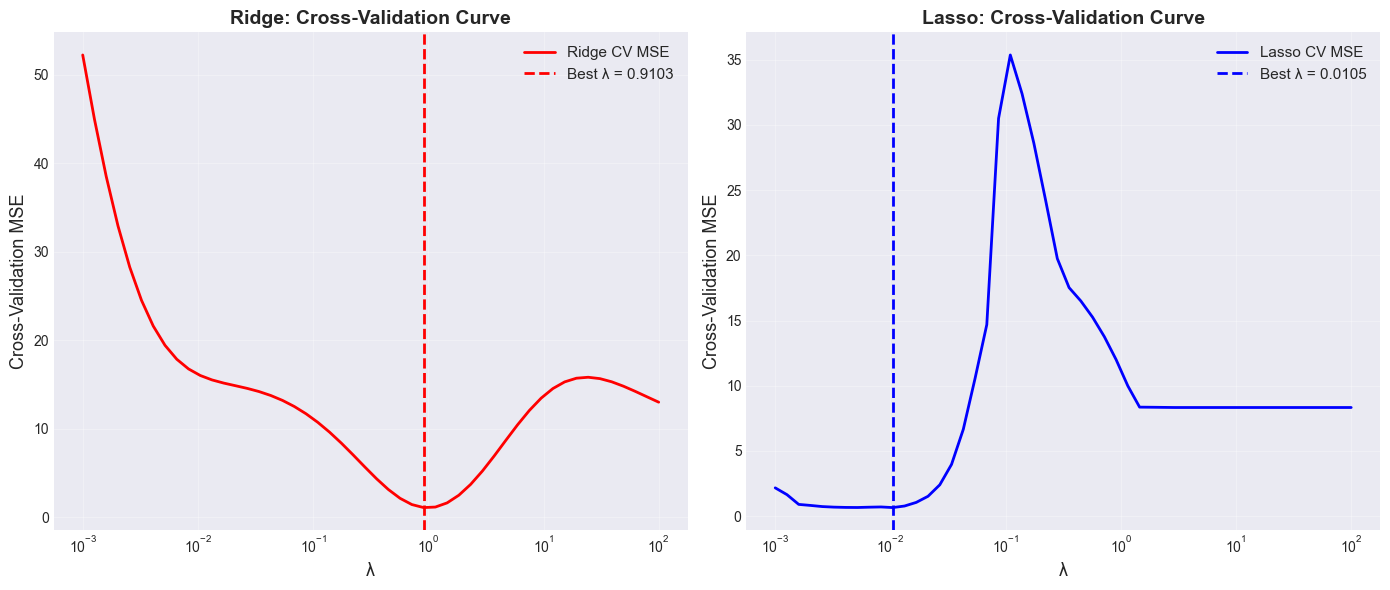


Cross-validation finds optimal λ that minimizes test error
Too small λ → overfitting; too large λ → underfitting


In [42]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score

# Generate larger dataset for CV
X_large, y_large = generate_data(n_samples=200, noise=0.8)
poly = PolynomialFeatures(degree=10, include_bias=False)
X_large_poly = poly.fit_transform(X_large)
scaler = StandardScaler()
X_large_scaled = scaler.fit_transform(X_large_poly)

# Define range of alphas
alphas = np.logspace(-3, 2, 50)

# Ridge CV
print("Performing Ridge Cross-Validation...")
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_large_scaled, y_large)
print(f"Best Ridge λ: {ridge_cv.alpha_:.4f}")

# Lasso CV
print("\nPerforming Lasso Cross-Validation...")
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_large_scaled, y_large)
print(f"Best Lasso λ: {lasso_cv.alpha_:.4f}")

# Compute CV scores for different alphas
ridge_scores = []
lasso_scores = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(
        ridge, X_large_scaled, y_large, cv=5, scoring="neg_mean_squared_error"
    )
    ridge_scores.append(-scores.mean())

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    scores = cross_val_score(
        lasso, X_large_scaled, y_large, cv=5, scoring="neg_mean_squared_error"
    )
    lasso_scores.append(-scores.mean())

# Plot CV curves
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.semilogx(alphas, ridge_scores, "r-", linewidth=2, label="Ridge CV MSE")
plt.axvline(
    ridge_cv.alpha_,
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Best λ = {ridge_cv.alpha_:.4f}",
)
plt.xlabel("λ", fontsize=13)
plt.ylabel("Cross-Validation MSE", fontsize=13)
plt.title("Ridge: Cross-Validation Curve", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(alphas, lasso_scores, "b-", linewidth=2, label="Lasso CV MSE")
plt.axvline(
    lasso_cv.alpha_,
    color="b",
    linestyle="--",
    linewidth=2,
    label=f"Best λ = {lasso_cv.alpha_:.4f}",
)
plt.xlabel("λ", fontsize=13)
plt.ylabel("Cross-Validation MSE", fontsize=13)
plt.title("Lasso: Cross-Validation Curve", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCross-validation finds optimal λ that minimizes test error")
print("Too small λ → overfitting; too large λ → underfitting")

---

## Part 7: Comparing All Methods

Final comparison of OLS, Ridge, and Lasso on the same dataset.


                                   FINAL MODEL COMPARISON
Method     Train MSE    Test MSE     Train R²     Test R²      ||β||₁     ||β||₂     Features  
----------------------------------------------------------------------------------------------------
OLS        0.6177       0.6059       0.9137       0.8718       51.28      19.91      10        
Ridge      0.6570       0.6546       0.9082       0.8615       9.52       4.15       10        
Lasso      0.6491       0.5861       0.9094       0.8760       7.93       4.97       5         


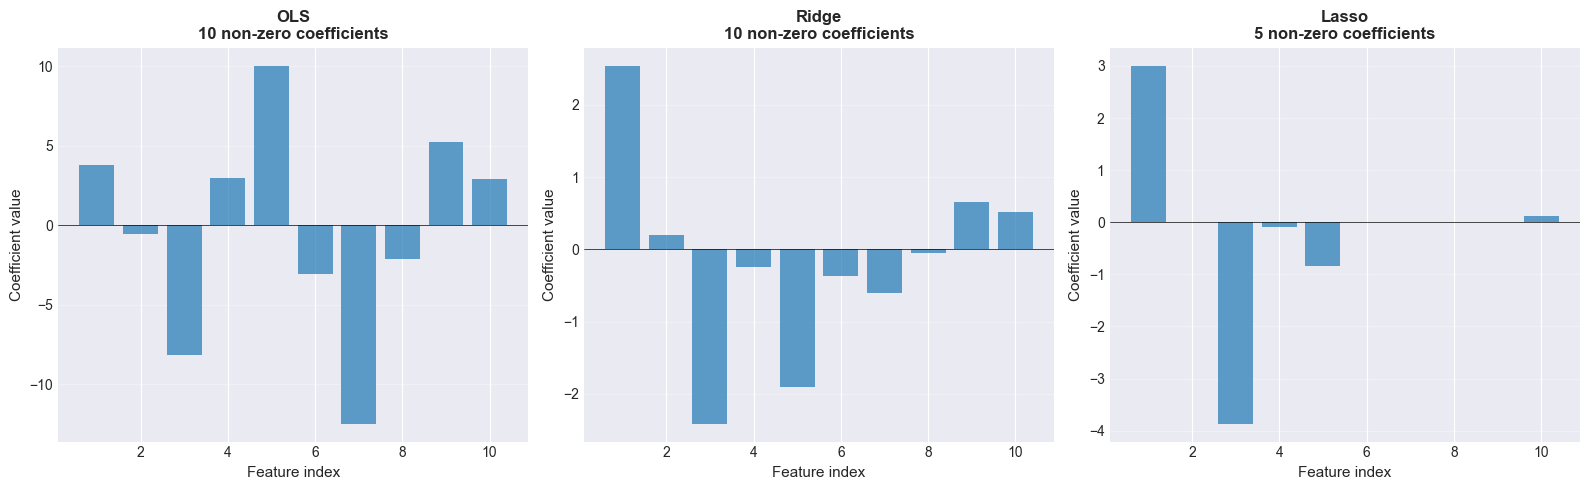


KEY OBSERVATIONS:
1. OLS: May overfit (low train error, higher test error), large coefficients
2. Ridge: Shrinks all coefficients, improves generalization, keeps all features
3. Lasso: Sparse solution (few features), automatic feature selection, best interpretability

Choose method based on your goal: prediction accuracy vs interpretability


In [43]:
# Train final models with best alphas
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=ridge_cv.alpha_),
    "Lasso": Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
}

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_large_scaled, y_large, test_size=0.3, random_state=42
)

# Train and evaluate
results_comparison = []

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Coefficient stats
    coef_l1 = np.sum(np.abs(model.coef_))
    coef_l2 = np.linalg.norm(model.coef_)
    n_nonzero = np.sum(np.abs(model.coef_) > 1e-5)

    results_comparison.append(
        {
            "Method": name,
            "Train MSE": train_mse,
            "Test MSE": test_mse,
            "Train R²": train_r2,
            "Test R²": test_r2,
            "||β||₁": coef_l1,
            "||β||₂": coef_l2,
            "Non-zero": n_nonzero,
        }
    )

# Print comparison table
print("\n" + "=" * 100)
print(" " * 35 + "FINAL MODEL COMPARISON")
print("=" * 100)
print(
    f"{'Method':<10} {'Train MSE':<12} {'Test MSE':<12} {'Train R²':<12} {'Test R²':<12} {'||β||₁':<10} {'||β||₂':<10} {'Features':<10}"
)
print("-" * 100)

for r in results_comparison:
    print(
        f"{r['Method']:<10} {r['Train MSE']:<12.4f} {r['Test MSE']:<12.4f} "
        f"{r['Train R²']:<12.4f} {r['Test R²']:<12.4f} "
        f"{r['||β||₁']:<10.2f} {r['||β||₂']:<10.2f} {r['Non-zero']:<10}"
    )

print("=" * 100)

# Visualize coefficients
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, model) in enumerate(models.items()):
    axes[idx].bar(range(1, len(model.coef_) + 1), model.coef_, alpha=0.7)
    axes[idx].axhline(y=0, color="k", linestyle="-", linewidth=0.5)
    axes[idx].set_xlabel("Feature index", fontsize=11)
    axes[idx].set_ylabel("Coefficient value", fontsize=11)
    axes[idx].set_title(
        f'{name}\n{results_comparison[idx]["Non-zero"]} non-zero coefficients',
        fontsize=12,
        fontweight="bold",
    )
    axes[idx].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n" + "=" * 100)
print("KEY OBSERVATIONS:")
print("=" * 100)
print("1. OLS: May overfit (low train error, higher test error), large coefficients")
print("2. Ridge: Shrinks all coefficients, improves generalization, keeps all features")
print(
    "3. Lasso: Sparse solution (few features), automatic feature selection, best interpretability"
)
print("\nChoose method based on your goal: prediction accuracy vs interpretability")
print("=" * 100)

---

## Part 8: Bayesian Linear Regression with Uncertainty

Beyond point estimates (Ridge/Lasso), full Bayesian inference provides uncertainty quantification:
- Posterior distribution over coefficients
- Predictive uncertainty for new data
- Epistemic (model) vs aleatoric (noise) uncertainty

In [44]:
from sklearn.linear_model import BayesianRidge
from scipy import stats

# Generate test data with known properties
np.random.seed(42)
n_samples = 100
X_bayes = np.random.randn(n_samples, 5)
true_beta = np.array([2.0, -1.5, 0.0, 3.0, -0.5])
noise_std = 1.0
y_bayes = X_bayes @ true_beta + noise_std * np.random.randn(n_samples)

# Split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bayes, y_bayes, test_size=0.3, random_state=42
)

# Standardize
scaler = StandardScaler()
X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)

print("=" * 80)
print("Bayesian Linear Regression: Uncertainty Quantification")
print("=" * 80)
print(f"\nTrue coefficients: {true_beta}")
print(f"True noise std: {noise_std:.2f}")
print(f"Training samples: {len(X_train_b)}")
print(f"Features: {X_train_b.shape[1]}")

Bayesian Linear Regression: Uncertainty Quantification

True coefficients: [ 2.  -1.5  0.   3.  -0.5]
True noise std: 1.00
Training samples: 70
Features: 5


### Compare Ridge vs Bayesian Ridge

In [45]:
# Fit Ridge (point estimate only)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_b_scaled, y_train_b)

# Fit Bayesian Ridge (full posterior)
bayes_ridge = BayesianRidge(compute_score=True)
bayes_ridge.fit(X_train_b_scaled, y_train_b)

# Compare coefficients
print("\n" + "=" * 80)
print("Coefficient Comparison")
print("=" * 80)
print(
    f"{'Feature':<10} {'True':<12} {'Ridge':<12} {'Bayes Mean':<15} {'Bayes Std':<12}"
)
print("-" * 80)

for i in range(len(true_beta)):
    # Bayesian Ridge provides posterior mean (same as Ridge approximately)
    # but also uncertainty
    print(
        f"β_{i:<8} {true_beta[i]:<12.3f} {ridge.coef_[i]:<12.3f} "
        f"{bayes_ridge.coef_[i]:<15.3f} {np.sqrt(bayes_ridge.sigma_[i, i]):<12.3f}"
    )

print("\nRidge and Bayesian Ridge give similar point estimates")
print("But Bayesian Ridge also provides uncertainty (std) for each coefficient")


Coefficient Comparison
Feature    True         Ridge        Bayes Mean      Bayes Std   
--------------------------------------------------------------------------------
β_0        2.000        1.837        1.853           0.115       
β_1        -1.500       -1.421       -1.433          0.115       
β_2        0.000        0.025        0.030           0.114       
β_3        3.000        2.968        2.998           0.114       
β_4        -0.500       -0.564       -0.568          0.115       

Ridge and Bayesian Ridge give similar point estimates
But Bayesian Ridge also provides uncertainty (std) for each coefficient
